In [1]:
!pip install pdfplumber pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 6.3 MB/s  0:00:01m 5.8 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 14.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [pdfplumber]━━━━━━━ 2/3 [pdfplumber]


In [2]:
import pdfplumber
import pandas as pd
import numpy as np
import re

# 定义文件路径
pdf_path = "2024全国锦标赛.pdf"
extracted_data = []

# 定义需要提取的核心列名
target_columns = ["项目", "组别", "参赛单位", "姓名", "成绩"]

print("开始解析 PDF 表格数据...")

with pdfplumber.open(pdf_path) as pdf:
    for i, page in enumerate(pdf.pages):
        # 提取当前页的所有表格
        tables = page.extract_tables()
        for table in tables:
            if not table:
                continue
                
            # 清理表头中的换行符和空格
            headers = [re.sub(r'\s+', '', str(h)) if h else '' for h in table[0]]
            
            # 校验是否为包含所需字段的数据表
            if not all(col in headers for col in ["项目", "组别", "成绩"]):
                continue
            
            # 遍历数据行
            for row in table[1:]:
                # 清理单元格内的换行符（如 "30秒单摇跳\n(双脚轮换跳)"）
                clean_row = [re.sub(r'\s+', '', str(cell)) if cell else '' for cell in row]
                
                # 补齐长度不一致的行
                if len(clean_row) < len(headers):
                    clean_row.extend([''] * (len(headers) - len(clean_row)))
                    
                row_dict = dict(zip(headers, clean_row))
                event_name = row_dict.get("项目", "")
                
                # 筛选目标项目（包含30秒单摇或3分钟单摇）
                if "30秒单摇" in event_name or "3分钟单摇" in event_name:
                    # 仅保留所需列
                    filtered_dict = {col: row_dict.get(col, "") for col in target_columns}
                    extracted_data.append(filtered_dict)

# 转换为 DataFrame
df = pd.DataFrame(extracted_data)

# 数据清洗与预处理
print("正在清洗数据...")

# 1. 将成绩转换为数值类型，无法转换的（如"弃权", "抢", "着装不符"）转为 NaN
df['成绩'] = pd.to_numeric(df['成绩'], errors='coerce')

# 2. 剔除无效成绩 (NaN)
df_clean = df.dropna(subset=['成绩']).copy()

# 3. 提取特征：从"项目"中区分时间（30秒/3分钟）
df_clean['时长'] = df_clean['项目'].apply(lambda x: '30s' if '30秒' in x else '3min')

# 4. 提取特征：从"组别"中拆分年龄和性别
df_clean['年龄段'] = df_clean['组别'].str.extract(r'(\d+-\d+岁|16岁及以上)')
df_clean['性别'] = df_clean['组别'].str.extract(r'(男子|女子)')

# 预览处理后的数据
display(df_clean.head())

# 导出为 CSV，供后续统计分析使用
output_filename = "jump_rope_cleaned_data.csv"
df_clean.to_csv(output_filename, index=False, encoding='utf-8-sig')
print(f"数据提取完成，有效样本量: {len(df_clean)}，已保存为 {output_filename}")

开始解析 PDF 表格数据...
正在清洗数据...


,项目,组别,参赛单位,姓名,成绩,时长,年龄段,性别
0,30秒单摇跳（双脚轮换跳）,9-11岁组女子组,吉林省跳绳协会,赵一桐,200.0,30s,9-11岁,女子
1,30秒单摇跳（双脚轮换跳）,9-11岁组女子组,广东省佛山市顺德区勒流东风小学跃动少年花样跳绳队,蓝依婧,197.0,30s,9-11岁,女子
2,30秒单摇跳（双脚轮换跳）,9-11岁组女子组,广西壮族自治区代表队,林嘉欣,196.0,30s,9-11岁,女子
3,30秒单摇跳（双脚轮换跳）,9-11岁组女子组,广西壮族自治区代表队,韦沅沅,194.0,30s,9-11岁,女子
4,30秒单摇跳（双脚轮换跳）,9-11岁组女子组,重庆黔江区新华小学跳绳队,谢曦珮,194.0,30s,9-11岁,女子


数据提取完成，有效样本量: 725，已保存为 jump_rope_cleaned_data.csv


findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
/var/folders/mj/ctj8wtps57d756zwwnpgfqkm0000gn/T/ipykernel_55765/2090862149.py:34: UserWarning: Glyph 23681 (\N{CJK UNIFIED IDEOGRAPH-5C81}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
/var/folders/mj/ctj8wtps57d756zwwnpgfqkm0000gn/T/ipykernel_55765/2090862149.py:34: UserWarning: Glyph 21450 (\N{CJK UNIFIED IDEOGRAPH-53CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mj/ctj8wtps57d756zwwnpgfqkm0000gn/T/ipykernel_55765/2090862149.py:34: UserWarning: Glyph 20197 (\N{CJK UNIFIED IDEOGRAPH-4EE5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mj/ctj8wtps57d756zwwnpgfqkm0000gn/T/ipykernel_55765/2090862149.py:34: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
findfont: Font family 'SimHei' not found.
findfo

=== 描述性统计汇总 ===
                count    mean     std     max    min
时长   年龄段    性别                                      
30s  12-15岁 女子     59  198.97  128.06   712.0   76.0
            男子     85  281.36  204.77   746.0  122.0
     16岁及以上 女子     19  199.37  107.35   530.0   68.0
            男子     52  228.73  147.89   780.0  100.0
     9-11岁  女子     74  286.72  206.80   754.0  124.0
            男子     98  276.36  201.35   772.0   82.0
3min 12-15岁 女子     47  833.51  126.96  1016.0  272.0
            男子     54  881.70  117.03  1048.0  618.0
     16岁及以上 女子     17  806.47  142.13  1032.0  522.0
            男子     39  875.49  112.45  1090.0  590.0
     9-11岁  女子     48  898.21  110.02  1062.0  568.0
            男子     62  898.94  118.52  1100.0  502.0


findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not

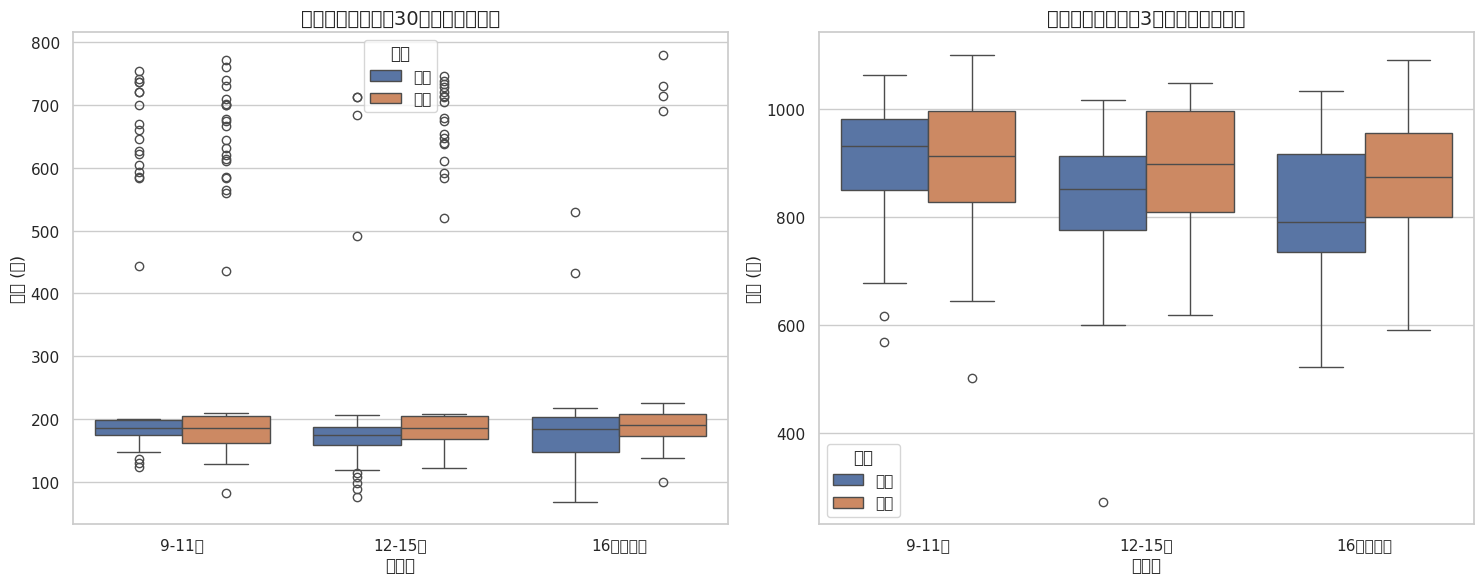

findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
/var/folders/mj/ctj8wtps57d756zwwnpgfqkm0000gn/T/ipykernel_55765/2090862149.py:88: UserWarning: Glyph 31186 (\N{CJK UNIFIED IDEOGRAPH-79D2}) missing from font(s) DejaVu Sans.
  plt.savefig('相关性散点图.png', dpi=300)
/var/folders/mj/ctj8wtps57d756zwwnpgfqkm0000gn/T/ipykernel_55765/2090862149.py:88: UserWarning: Glyph 21333 (\N{CJK UNIFIED IDEOGRAPH-5355}) missing from font(s) DejaVu Sans.
  plt.savefig('相关性散点图.png', dpi=300)
/var/folders/mj/ctj8wtps57d756zwwnpgfqkm0000gn/T/ipykernel_55765/2090862149.py:88: UserWarning: Glyph 25671 (\N{CJ


=== 年龄差异分析 (单因素方差分析) ===
项目: 30s, F值: 2.65, P值: 0.0717
项目: 3min, F值: 3.80, P值: 0.0236
  结论: 不同年龄段之间存在显著性差异。

=== 性别差异分析 (独立样本 T检验) ===
项目: 30s | 年龄: 9-11岁 | T值: -0.33, P值: 0.7426
项目: 30s | 年龄: 12-15岁 | T值: 2.97, P值: 0.0035
  结论: 男女成绩存在显著性差异。
项目: 30s | 年龄: 16岁及以上 | T值: 0.92, P值: 0.3645
项目: 3min | 年龄: 9-11岁 | T值: 0.03, P值: 0.9736
项目: 3min | 年龄: 12-15岁 | T值: 1.97, P值: 0.0514
项目: 3min | 年龄: 16岁及以上 | T值: 1.77, P值: 0.0881

=== 爆发力与耐力相关性分析 ===
匹配到的双项选手数量: 301人
皮尔逊相关系数 r = 0.718, P值 = 0.0000


findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not

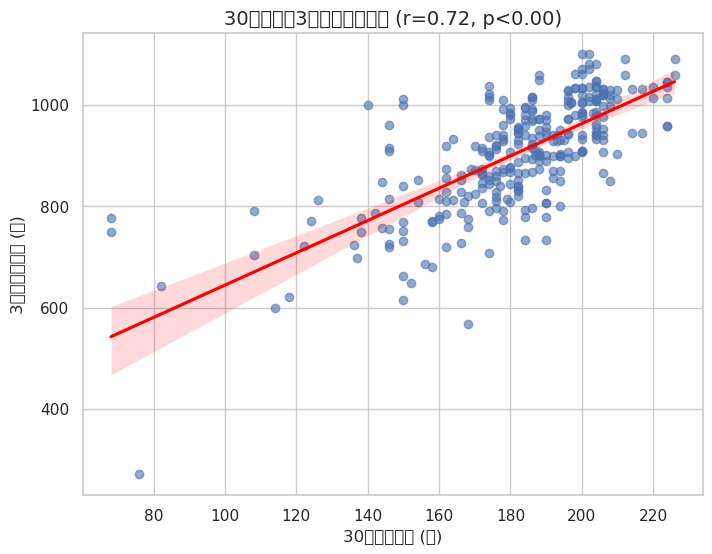

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. 设置中文字体和学术图表风格
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows用黑体，Mac请改为 'Arial Unicode MS'
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
sns.set_theme(style="whitegrid", font='SimHei')
# 2. 读取清洗后的数据
# 假设上一步生成的文件名为 'jump_rope_cleaned_data.csv'
df = pd.read_csv('jump_rope_cleaned_data.csv')

# ==========================================
# 分析一：描述性统计
# ==========================================
print("=== 描述性统计汇总 ===")
desc_stats = df.groupby(['时长', '年龄段', '性别'])['成绩'].agg(['count', 'mean', 'std', 'max', 'min']).round(2)
print(desc_stats)
# 导出为表格供论文使用
desc_stats.to_excel('描述性统计表.xlsx')

# 绘制箱型图 (30秒和3分钟分开看)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.boxplot(data=df[df['时长']=='30s'], x='年龄段', y='成绩', hue='性别', ax=axes[0], order=['9-11岁', '12-15岁', '16岁及以上'])
axes[0].set_title('不同年龄及性别：30秒单摇成绩分布', fontsize=14)
axes[0].set_ylabel('成绩 (次)')

sns.boxplot(data=df[df['时长']=='3min'], x='年龄段', y='成绩', hue='性别', ax=axes[1], order=['9-11岁', '12-15岁', '16岁及以上'])
axes[1].set_title('不同年龄及性别：3分钟单摇成绩分布', fontsize=14)
axes[1].set_ylabel('成绩 (次)')

plt.tight_layout()
plt.savefig('成绩分布箱型图.png', dpi=300)
plt.show()

# ==========================================
# 分析二：年龄差异分析 (方差分析 ANOVA)
# ==========================================
print("\n=== 年龄差异分析 (单因素方差分析) ===")
for duration in ['30s', '3min']:
    data_30s = df[df['时长'] == duration]
    age_groups = [group['成绩'].values for name, group in data_30s.groupby('年龄段')]
    f_stat, p_val = stats.f_oneway(*age_groups)
    print(f"项目: {duration}, F值: {f_stat:.2f}, P值: {p_val:.4f}")
    if p_val < 0.05:
        print("  结论: 不同年龄段之间存在显著性差异。")

# ==========================================
# 分析三：性别差异分析 (独立样本 T检验)
# ==========================================
print("\n=== 性别差异分析 (独立样本 T检验) ===")
for duration in ['30s', '3min']:
    for age in ['9-11岁', '12-15岁', '16岁及以上']:
        subset = df[(df['时长'] == duration) & (df['年龄段'] == age)]
        male = subset[subset['性别'] == '男子']['成绩'].values
        female = subset[subset['性别'] == '女子']['成绩'].values
        
        if len(male) > 2 and len(female) > 2:
            t_stat, p_val = stats.ttest_ind(male, female, equal_var=False)
            print(f"项目: {duration} | 年龄: {age} | T值: {t_stat:.2f}, P值: {p_val:.4f}")
            if p_val < 0.05:
                print("  结论: 男女成绩存在显著性差异。")

# ==========================================
# 分析四：相关性分析 (30秒 vs 3分钟)
# ==========================================
print("\n=== 爆发力与耐力相关性分析 ===")
# 找到同时参加了两项的选手 (依据姓名和单位匹配)
df_30s = df[df['时长'] == '30s'][['参赛单位', '姓名', '成绩']].rename(columns={'成绩': '30秒成绩'})
df_3min = df[df['时长'] == '3min'][['参赛单位', '姓名', '成绩']].rename(columns={'成绩': '3分钟成绩'})

# 内连接，获取同时具有两项成绩的人员
df_merge = pd.merge(df_30s, df_3min, on=['参赛单位', '姓名'], how='inner')

if len(df_merge) > 5:
    r, p = stats.pearsonr(df_merge['30秒成绩'], df_merge['3分钟成绩'])
    print(f"匹配到的双项选手数量: {len(df_merge)}人")
    print(f"皮尔逊相关系数 r = {r:.3f}, P值 = {p:.4f}")
    
    # 绘制相关性散点图及拟合线
    plt.figure(figsize=(8, 6))
    sns.regplot(data=df_merge, x='30秒成绩', y='3分钟成绩', scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
    plt.title(f'30秒速度与3分钟耐力相关性 (r={r:.2f}, p<{p:.2f})', fontsize=14)
    plt.xlabel('30秒单摇成绩 (次)')
    plt.ylabel('3分钟单摇成绩 (次)')
    plt.savefig('相关性散点图.png', dpi=300)
    plt.show()
else:
    print("匹配到的兼项选手不足，无法进行稳定的相关性分析。")

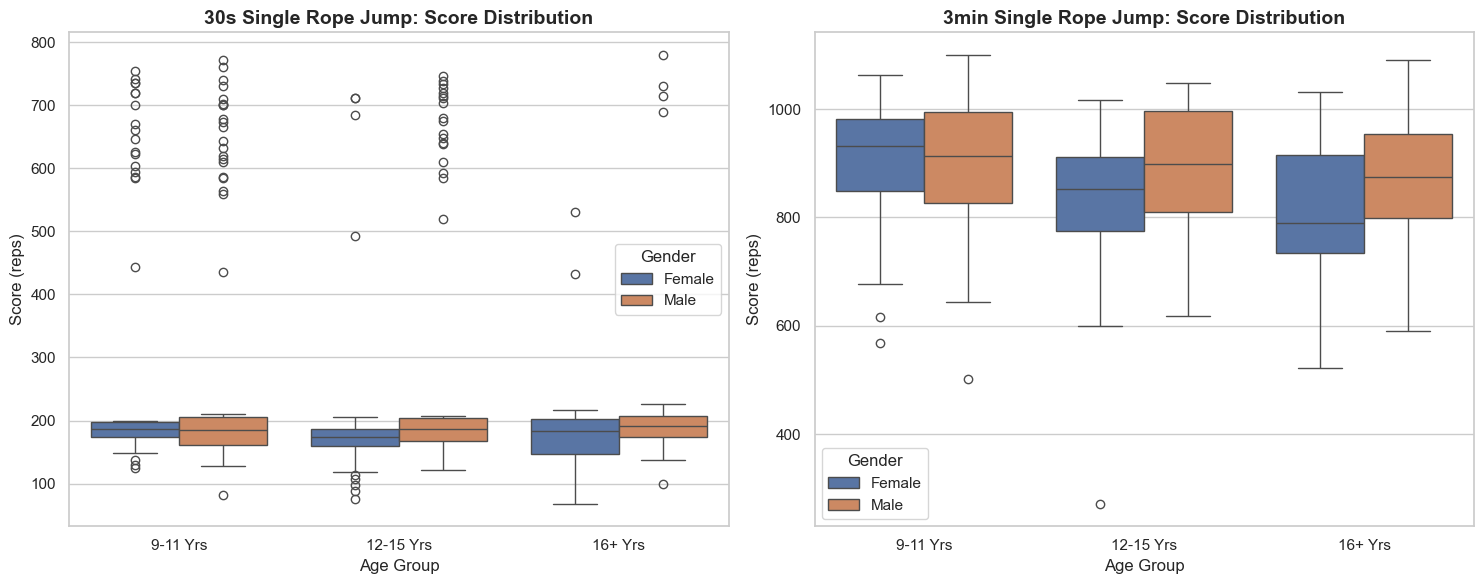

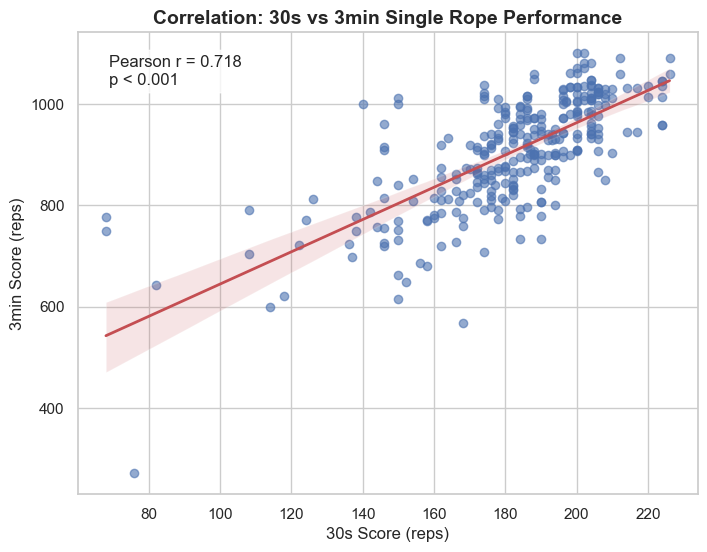

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. 恢复 Matplotlib 的默认英文字体设置（彻底告别乱码）
plt.rcParams['font.sans-serif'] = ['sans-serif'] 
plt.rcParams['axes.unicode_minus'] = True
sns.set_theme(style="whitegrid")

# 2. 读取数据
df = pd.read_csv('jump_rope_cleaned_data.csv')

# 3. 将数据中的中文映射为标准英文（专为学术图表准备）
df['Gender'] = df['性别'].map({'男子': 'Male', '女子': 'Female'})
df['Age Group'] = df['年龄段'].map({'9-11岁': '9-11 Yrs', '12-15岁': '12-15 Yrs', '16岁及以上': '16+ Yrs'})
df['Duration'] = df['时长']
df['Score'] = df['成绩']

# 定义年龄组的排序顺序
age_order = ['9-11 Yrs', '12-15 Yrs', '16+ Yrs']

# ==========================================
# 绘制全英文图表 1：成绩分布箱型图
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 30秒项目
sns.boxplot(data=df[df['Duration']=='30s'], x='Age Group', y='Score', hue='Gender', ax=axes[0], order=age_order)
axes[0].set_title('30s Single Rope Jump: Score Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score (reps)')
axes[0].set_xlabel('Age Group')

# 3分钟项目
sns.boxplot(data=df[df['Duration']=='3min'], x='Age Group', y='Score', hue='Gender', ax=axes[1], order=age_order)
axes[1].set_title('3min Single Rope Jump: Score Distribution', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Score (reps)')
axes[1].set_xlabel('Age Group')

plt.tight_layout()
plt.savefig('Score_Distribution_Boxplot.png', dpi=300)
plt.show()

# ==========================================
# 绘制全英文图表 2：相关性散点图
# ==========================================
df_30s = df[df['Duration'] == '30s'][['参赛单位', '姓名', 'Score']].rename(columns={'Score': 'Score_30s'})
df_3min = df[df['Duration'] == '3min'][['参赛单位', '姓名', 'Score']].rename(columns={'Score': 'Score_3min'})
df_merge = pd.merge(df_30s, df_3min, on=['参赛单位', '姓名'], how='inner')

if len(df_merge) > 5:
    r, p = stats.pearsonr(df_merge['Score_30s'], df_merge['Score_3min'])
    
    plt.figure(figsize=(8, 6))
    sns.regplot(data=df_merge, x='Score_30s', y='Score_3min', 
                scatter_kws={'alpha':0.6, 'color':'#4C72B0'}, 
                line_kws={'color':'#C44E52', 'linewidth':2})
    
    # 在图表上添加统计学文本
    plt.text(0.05, 0.95, f'Pearson r = {r:.3f}\np < 0.001', 
             transform=plt.gca().transAxes, fontsize=12, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
             
    plt.title('Correlation: 30s vs 3min Single Rope Performance', fontsize=14, fontweight='bold')
    plt.xlabel('30s Score (reps)')
    plt.ylabel('3min Score (reps)')
    plt.savefig('Correlation_Scatter.png', dpi=300)
    plt.show()